In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
# Replace 'path/to/your/dataset.csv' with the actual path to your dataset file.
# If your dataset is in a different format (e.g., Excel, JSON), please let me know.
df = pd.read_csv('/content/heart_disease_uci.csv')
display(df.head(10))

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [53]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 920
Number of columns: 16


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [55]:
y = df['num']
X = df.drop('num', axis=1)

# Binarize the target variable 'num'

In [56]:
# Binarize the target variable 'num'
# 0 = no heart disease, 1 = heart disease
y = y.apply(lambda x: 1 if x > 0 else 0)

print("Value counts for the binarized target variable (y):")
display(y.value_counts())

Value counts for the binarized target variable (y):


,count
num,
1,509
0,411


In [57]:
display(X.head(10))

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect


# Drop the 'id' column

In [58]:
# Drop the 'id' column as it's an identifier and not a predictor variable
X = X.drop('id', axis=1)

print("Predictor variables (X) after dropping 'id' column:")
display(X.head())

Predictor variables (X) after dropping 'id' column:


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


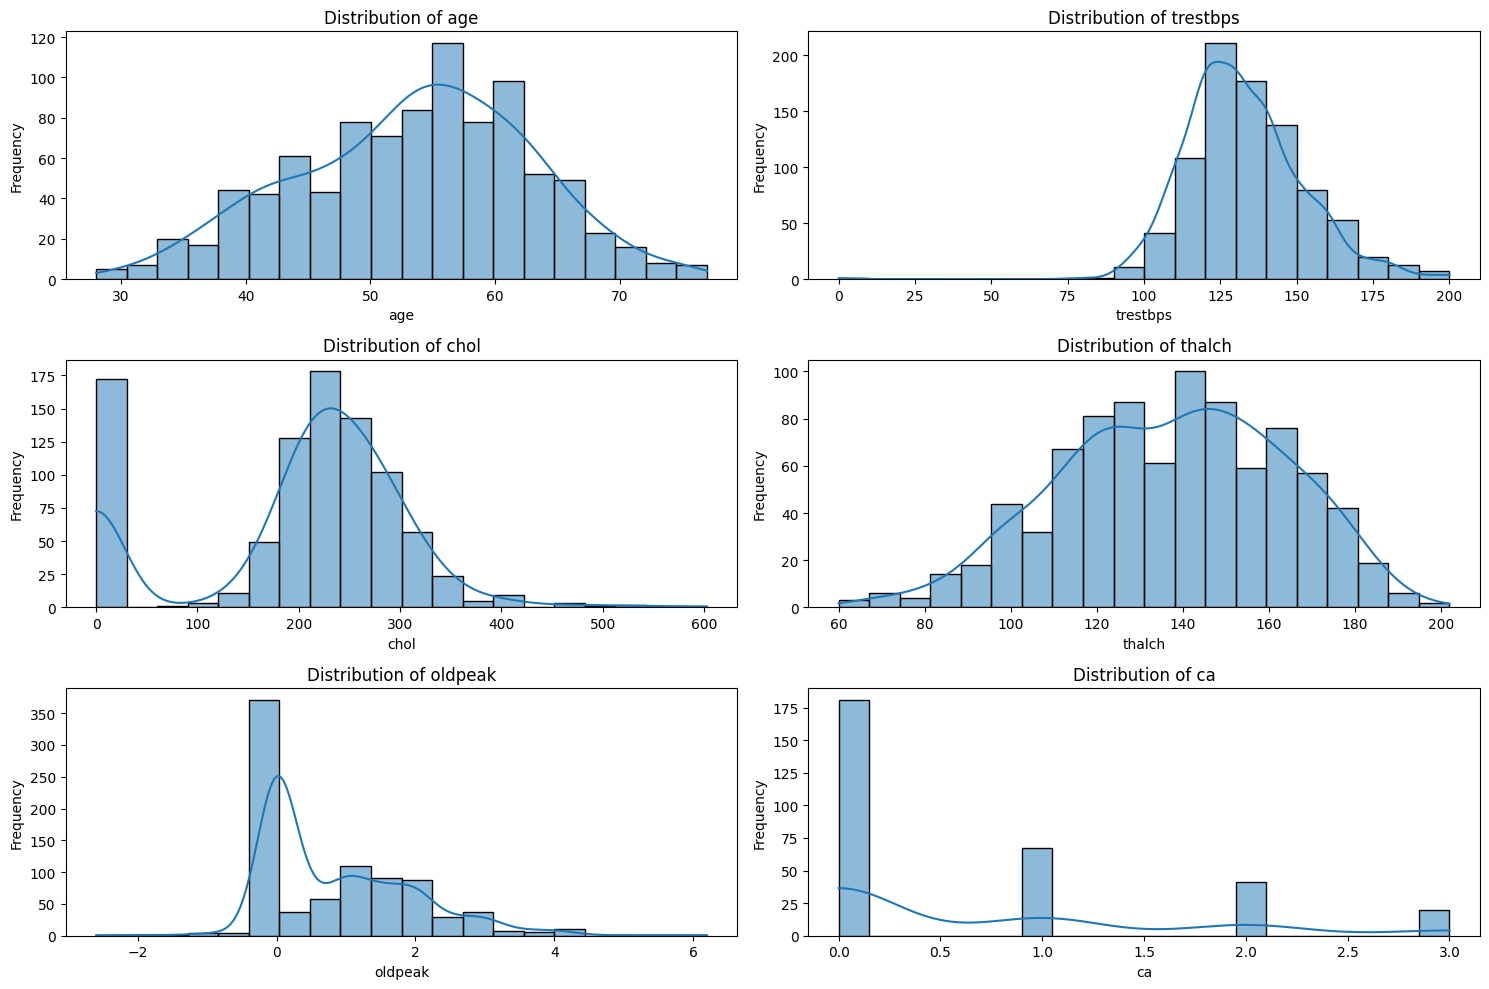

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(X[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_37113/2918323979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
/tmp/ipykernel_37113/2918323979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
/tmp/ipykernel_37113/2918323979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
/tmp/ipykernel_37113/2918323979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` 

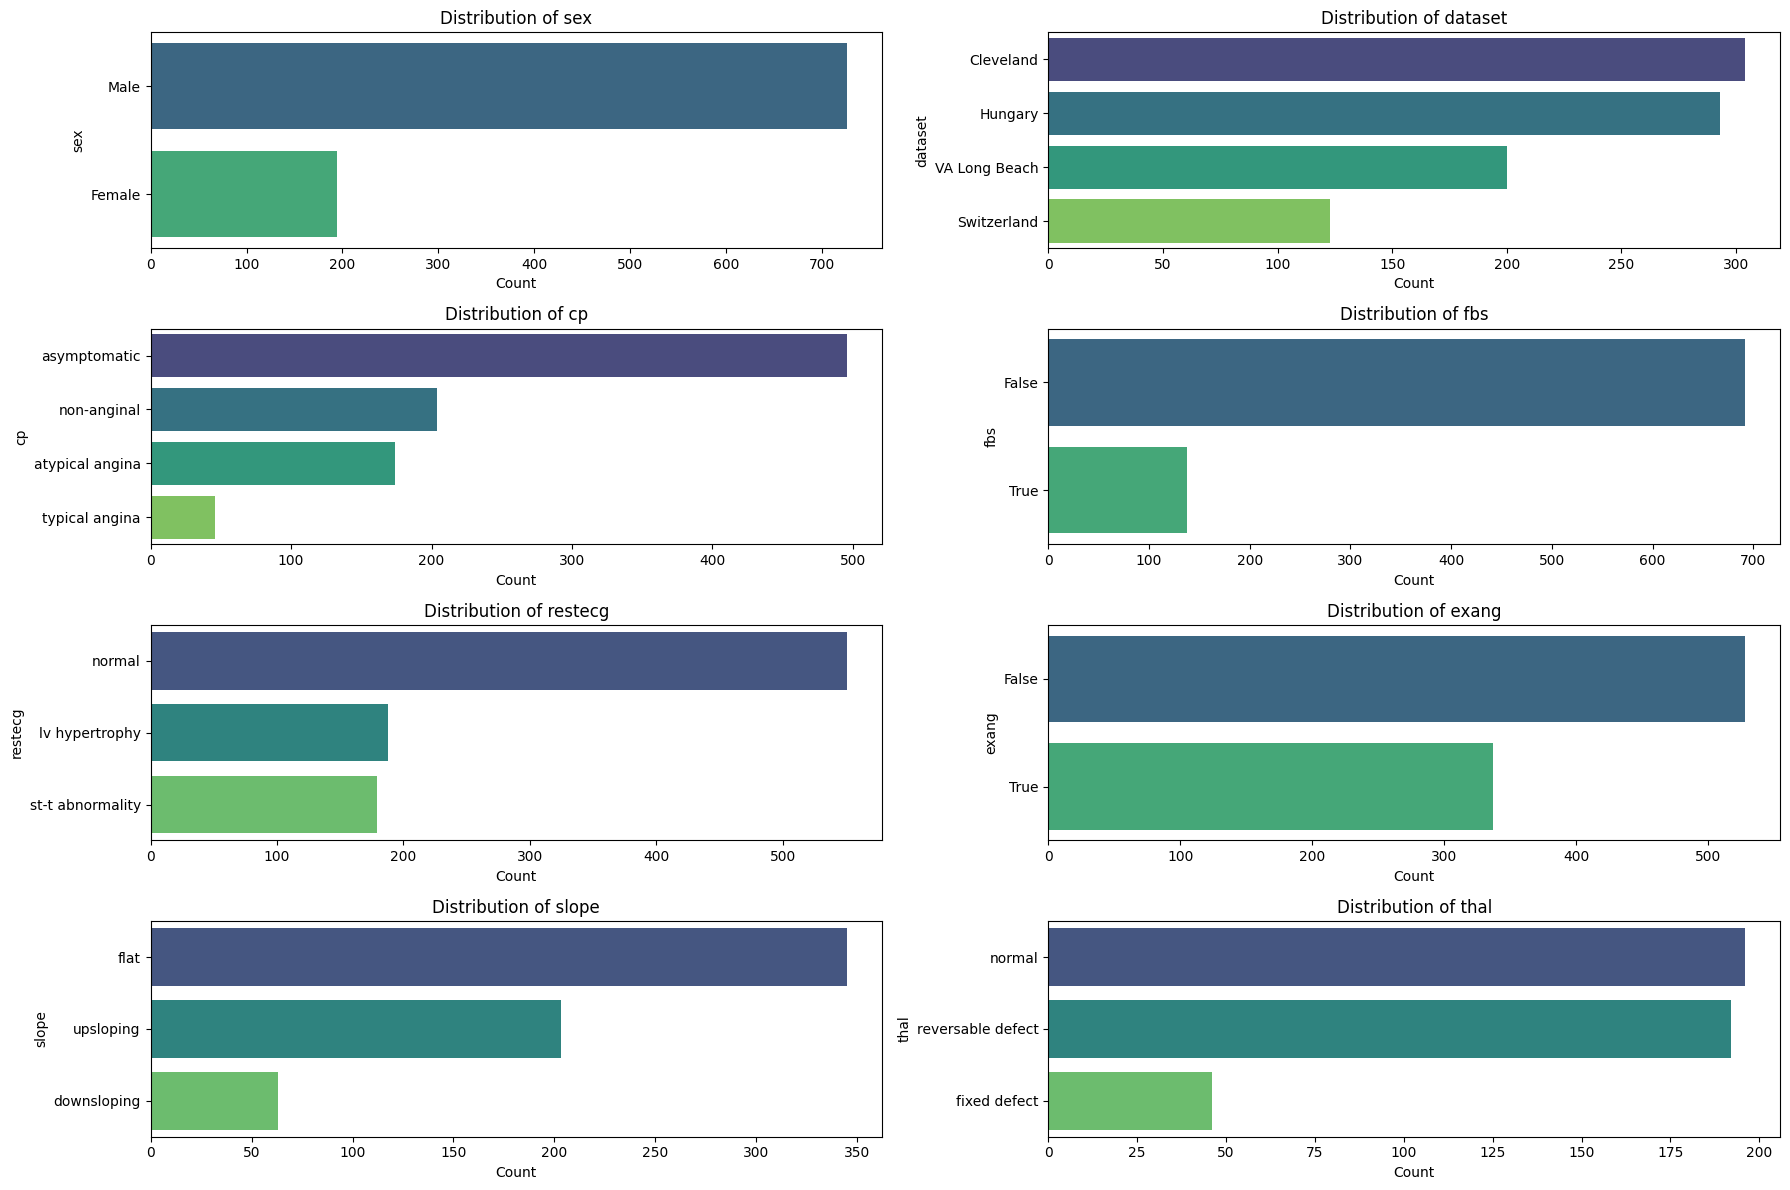

In [60]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#Missing values

In [61]:
print("Missing values in predictor variables (X):")
display(X.isnull().sum())

Missing values in predictor variables (X):


,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


#Percentage of missing values per column

In [62]:
missing_percentage = (X.isnull().sum() / len(X)) * 100
print("Percentage of missing values per column:")
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Percentage of missing values per column:


,0
ca,66.413043
thal,52.826087
slope,33.586957
fbs,9.782609
oldpeak,6.739130
trestbps,6.413043
exang,5.978261
thalch,5.978261
chol,3.260870
restecg,0.217391


## Drop columns with too many missing values

In [63]:
# Drop columns with too many missing values
X = X.drop(['ca', 'thal'], axis=1)

# Impute numerical columns with the mean
numerical_cols_to_impute = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numerical_cols_to_impute:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mean())

# Impute categorical columns with the mode
categorical_cols_to_impute = ['fbs', 'restecg', 'exang', 'slope']
for col in categorical_cols_to_impute:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values after imputation and dropping columns:")
display(X.isnull().sum())

Missing values after imputation and dropping columns:


/tmp/ipykernel_37113/898465453.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [64]:
print("Columns in the predictor variables (X):")
display(X.columns)

Columns in the predictor variables (X):


Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope'],
      dtype='object')

#Number of duplicate rows

In [65]:
num_duplicate_rows = X.duplicated().sum()
percentage_duplicate_rows = (num_duplicate_rows / len(X)) * 100
print(f"Number of duplicate rows in X: {num_duplicate_rows}")
print(f"Percentage of duplicate rows in X: {percentage_duplicate_rows:.2f}%")

Number of duplicate rows in X: 2
Percentage of duplicate rows in X: 0.22%


#Number of rows after removing duplicates

In [66]:
X = X.drop_duplicates()
# Align y with the new index of X after dropping duplicates
y = y.loc[X.index]
print(f"Number of rows after removing duplicates: {X.shape[0]}")

Number of rows after removing duplicates: 918


In [67]:
print("Summary statistics for numerical columns in X:")
display(X.describe())

Summary statistics for numerical columns in X:


,age,trestbps,chol,thalch,oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.137050,199.108693,137.542496,0.880702
std,9.432617,18.440088,109.074413,25.146684,1.054122
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,177.250000,120.000000,0.000000
50%,54.000000,130.000000,221.000000,138.000000,0.800000
75%,60.000000,140.000000,267.000000,155.750000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [68]:
print("Summary statistics for categorical columns in X:")
display(X.describe(include='object'))

Summary statistics for categorical columns in X:


,sex,dataset,cp,restecg,slope
count,918,918,918,918,918
unique,2,4,4,3,3
top,Male,Cleveland,asymptomatic,normal,flat
freq,725,304,496,552,652


#Value counts for categorical columns

In [69]:
print("Value counts for categorical columns in X:")
categorical_cols = X.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f"\nValue counts for column '{col}':")
    display(X[col].value_counts())

Value counts for categorical columns in X:

Value counts for column 'sex':


,count
sex,
Male,725
Female,193



Value counts for column 'dataset':


,count
dataset,
Cleveland,304
Hungary,292
VA Long Beach,199
Switzerland,123



Value counts for column 'cp':


,count
cp,
asymptomatic,496
non-anginal,203
atypical angina,173
typical angina,46



Value counts for column 'restecg':


,count
restecg,
normal,552
lv hypertrophy,188
st-t abnormality,178



Value counts for column 'slope':


,count
slope,
flat,652
upsloping,203
downsloping,63


In [70]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   dataset   918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  918 non-null    float64
 5   chol      918 non-null    float64
 6   fbs       918 non-null    bool   
 7   restecg   918 non-null    object 
 8   thalch    918 non-null    float64
 9   exang     918 non-null    bool   
 10  oldpeak   918 non-null    float64
 11  slope     918 non-null    object 
dtypes: bool(2), float64(4), int64(1), object(5)
memory usage: 80.7+ KB


#Binary encoding in sex column

In [71]:
X = pd.get_dummies(X, columns=['sex'], drop_first=True)
display(X.head())

,age,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,sex_Male
0,63,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,True
1,67,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,True
2,67,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,True
3,37,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,True
4,41,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,False


/tmp/ipykernel_37113/1141249178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X['sex_Male'], palette='viridis')


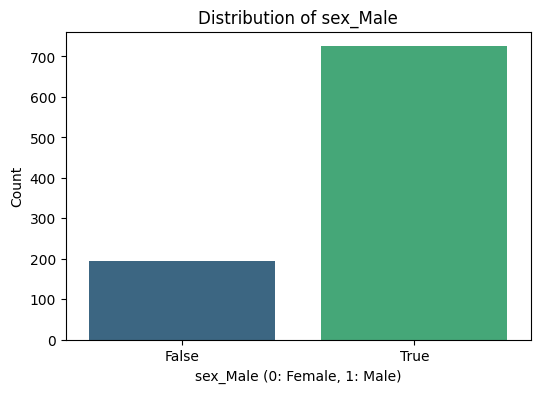

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=X['sex_Male'], palette='viridis')
plt.title('Distribution of sex_Male')
plt.xlabel('sex_Male (0: Female, 1: Male)')
plt.ylabel('Count')
plt.show()

#drop dataset column

In [73]:
X = X.drop('dataset', axis=1)
display(X.head())

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,sex_Male
0,63,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,True
1,67,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,True
2,67,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,True
3,37,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,True
4,41,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,False


#one hot encoding in cp column

In [74]:
X = pd.get_dummies(X, columns=['cp'], drop_first=False)
display(X.head())

,age,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,True,False,False,False,True
1,67,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,True,True,False,False,False
2,67,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,True,True,False,False,False
3,37,130.0,250.0,False,normal,187.0,False,3.5,downsloping,True,False,False,True,False
4,41,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,False,False,True,False,False


/tmp/ipykernel_37113/1979300077.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X[col], palette='viridis')
/tmp/ipykernel_37113/1979300077.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X[col], palette='viridis')
/tmp/ipykernel_37113/1979300077.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X[col], palette='viridis')
/tmp/ipykernel_37113/1979300077.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

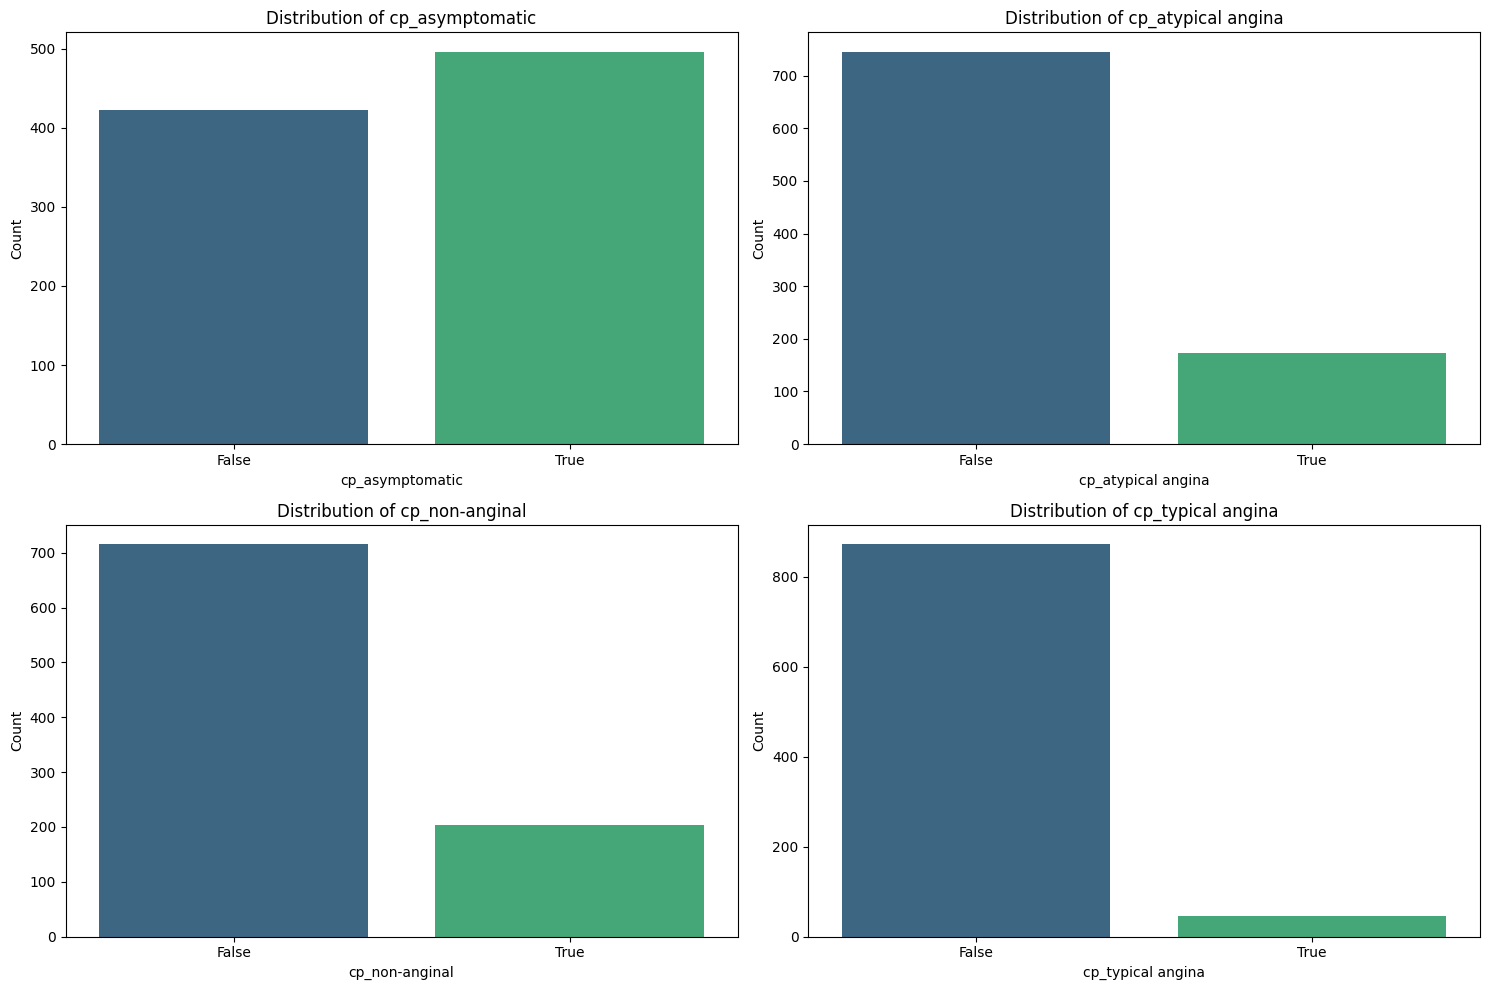

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the one-hot encoded 'cp' columns
cp_cols = [col for col in X.columns if col.startswith('cp_')]

plt.figure(figsize=(15, 10))
for i, col in enumerate(cp_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed based on number of cp_cols
    sns.countplot(x=X[col], palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Value counts for 'fbs' after conversion

In [76]:
X['fbs'] = X['fbs'].astype(int)
print("Value counts for 'fbs' after conversion:")
display(X['fbs'].value_counts())
print("Data types after converting 'fbs':")
display(X.info())

Value counts for 'fbs' after conversion:


,count
fbs,
0,780
1,138


Data types after converting 'fbs':
<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 918 non-null    int64  
 1   trestbps            918 non-null    float64
 2   chol                918 non-null    float64
 3   fbs                 918 non-null    int64  
 4   restecg             918 non-null    object 
 5   thalch              918 non-null    float64
 6   exang               918 non-null    bool   
 7   oldpeak             918 non-null    float64
 8   slope               918 non-null    object 
 9   sex_Male            918 non-null    bool   
 10  cp_asymptomatic     918 non-null    bool   
 11  cp_atypical angina  918 non-null    bool   
 12  cp_non-anginal      918 non-null    bool   
 13  cp_typical angina   918 non-null    bool   
dtypes: bool(6), float64(4), int64(2), object(2)
memory usage: 69.9+ KB


None

#one hot encoding restecg column

In [77]:
X = pd.get_dummies(X, columns=['restecg'], drop_first=False)
display(X.head())

,age,trestbps,chol,fbs,thalch,exang,oldpeak,slope,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality
0,63,145.0,233.0,1,150.0,False,2.3,downsloping,True,False,False,False,True,True,False,False
1,67,160.0,286.0,0,108.0,True,1.5,flat,True,True,False,False,False,True,False,False
2,67,120.0,229.0,0,129.0,True,2.6,flat,True,True,False,False,False,True,False,False
3,37,130.0,250.0,0,187.0,False,3.5,downsloping,True,False,False,True,False,False,True,False
4,41,130.0,204.0,0,172.0,False,1.4,upsloping,False,False,True,False,False,True,False,False


#one hot encoding slope column

In [78]:
X = pd.get_dummies(X, columns=['slope'], drop_first=False)
display(X.head())

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping
0,63,145.0,233.0,1,150.0,False,2.3,True,False,False,False,True,True,False,False,True,False,False
1,67,160.0,286.0,0,108.0,True,1.5,True,True,False,False,False,True,False,False,False,True,False
2,67,120.0,229.0,0,129.0,True,2.6,True,True,False,False,False,True,False,False,False,True,False
3,37,130.0,250.0,0,187.0,False,3.5,True,False,False,True,False,False,True,False,True,False,False
4,41,130.0,204.0,0,172.0,False,1.4,False,False,True,False,False,True,False,False,False,False,True


In [79]:
print("Processed Features (X) head:")
display(X.head())
print("Binarized Target Variable (y) head:")
display(y.head())

Processed Features (X) head:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping
0,63,145.0,233.0,1,150.0,False,2.3,True,False,False,False,True,True,False,False,True,False,False
1,67,160.0,286.0,0,108.0,True,1.5,True,True,False,False,False,True,False,False,False,True,False
2,67,120.0,229.0,0,129.0,True,2.6,True,True,False,False,False,True,False,False,False,True,False
3,37,130.0,250.0,0,187.0,False,3.5,True,False,False,True,False,False,True,False,True,False,False
4,41,130.0,204.0,0,172.0,False,1.4,False,False,True,False,False,True,False,False,False,False,True


Binarized Target Variable (y) head:


,num
0,0
1,1
2,1
3,0
4,0


#correlation matrix

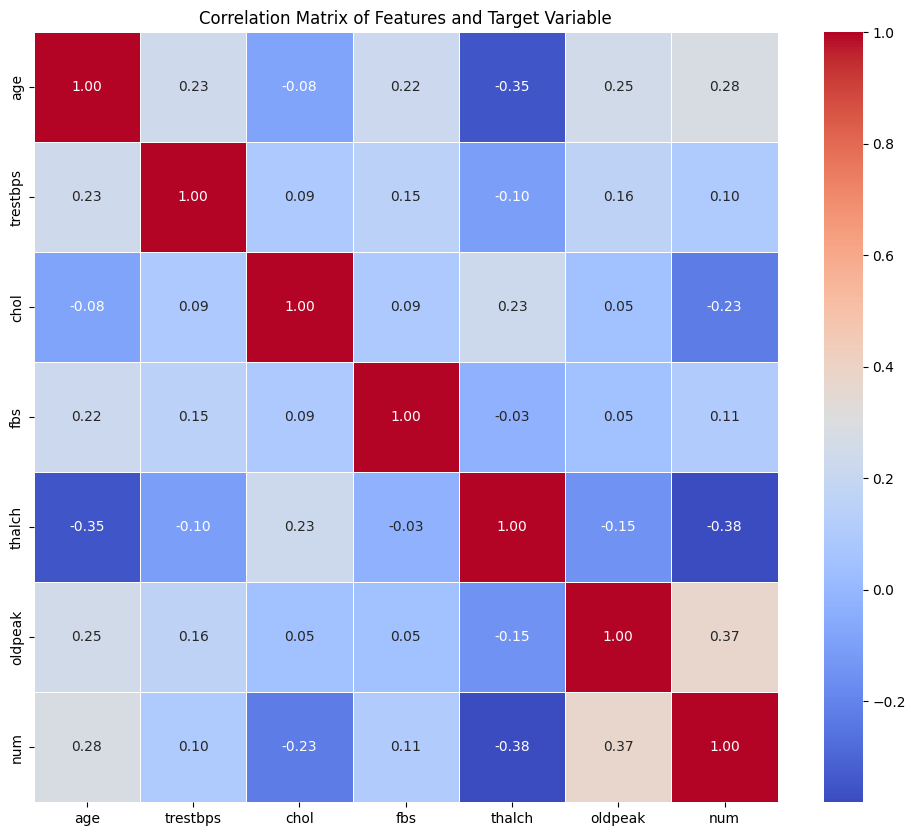

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all columns in X are numeric for correlation calculation
X_numeric = X.select_dtypes(include=np.number)

# Add the target variable 'y' to X_numeric for correlation analysis
df_corr = pd.concat([X_numeric, y], axis=1)

# Calculate the correlation matrix
corr_matrix = df_corr.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features and Target Variable')
plt.show()

#Distribution of oldpeak by Heart Disease Presence

/tmp/ipykernel_37113/1563681867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['oldpeak'], palette='viridis')


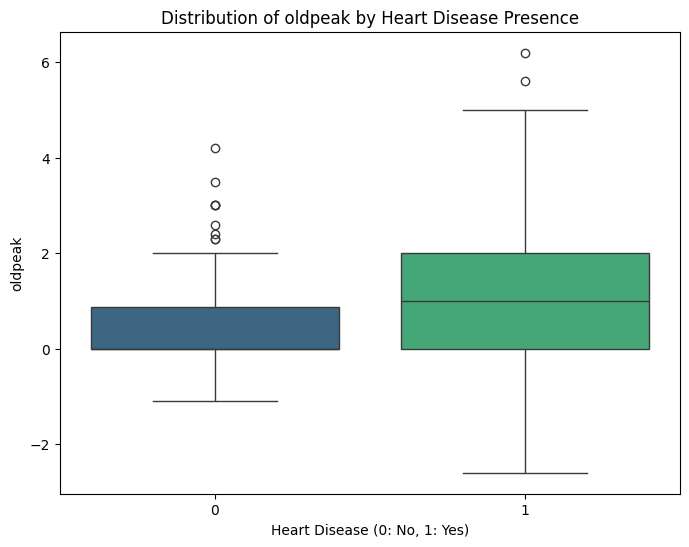

In [81]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X['oldpeak'], palette='viridis')
plt.title('Distribution of oldpeak by Heart Disease Presence')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('oldpeak')
plt.show()

#Distribution of thalch by Heart Disease Presence

/tmp/ipykernel_37113/3738858297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['thalch'], palette='viridis')


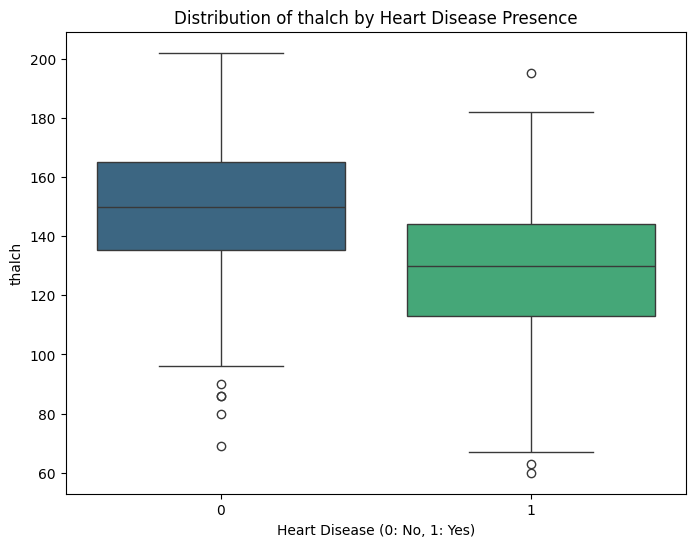

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X['thalch'], palette='viridis')
plt.title('Distribution of thalch by Heart Disease Presence')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('thalch')
plt.show()

#F-scores and p-values for each feature

In [83]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Calculate F-scores and p-values
f_scores, p_values = f_classif(X, y)

# Create a DataFrame to display the results
feature_selection_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})

# Sort by F-score in descending order to see the most important features first
feature_selection_results = feature_selection_results.sort_values(by='F-Score', ascending=False)

print("F-scores and p-values for each feature:")
display(feature_selection_results)

F-scores and p-values for each feature:


,Feature,F-Score,P-Value
8,cp_asymptomatic,333.651942,8.415228e-64
5,exang,210.678446,4.042628e-43
9,cp_atypical angina,176.482905,5.868475e-37
4,thalch,156.328942,3.120176e-33
6,oldpeak,148.402258,9.539159e-32
7,sex_Male,94.253184,2.821898e-21
0,age,79.160779,3.007953e-18
2,chol,49.719312,3.492421e-12
10,cp_non-anginal,43.517481,7.096217e-11
17,slope_upsloping,31.126535,3.182880e-08


#Chi-squared scores and p-values for categorical features

In [84]:
from sklearn.feature_selection import chi2
import pandas as pd

# Identify categorical columns (after one-hot encoding, these will be boolean or int)
# We need to select only non-negative features for chi2. Boolean features are fine.
categorical_features_for_chi2 = X.select_dtypes(include=['bool', 'int64']).columns.tolist()

# Exclude 'age' and 'fbs' if they are not truly categorical or if they are already handled by f_classif (they are numerical like)
# For simplicity, let's consider all boolean and integer columns created from one-hot encoding or directly as categorical for chi2.
# Reviewing the `X` df info, boolean columns are `sex_Male`, `cp_asymptomatic`, `cp_atypical angina`, `cp_non-anginal`, `cp_typical angina`,
# `restecg_lv hypertrophy`, `restecg_normal`, `restecg_st-t abnormality`, `slope_downsloping`, `slope_flat`, `slope_upsloping`
# and `fbs` is int64, `age` is int64. `age` is clearly numerical. `fbs` is also a numerical representation of a categorical feature.

# Let's be more specific about truly categorical features after encoding
chi2_features = [col for col in X.columns if X[col].dtype == 'bool']
# Also include fbs if it's considered categorical, as it's binary (0 or 1)
if 'fbs' in X.columns and X['fbs'].nunique() == 2:
    chi2_features.append('fbs')

# Ensure all features selected for chi2 are non-negative
X_chi2 = X[chi2_features]

# Calculate Chi-squared statistics and p-values
chi_scores, chi_p_values = chi2(X_chi2, y)

# Create a DataFrame to display the results
chi2_results = pd.DataFrame({
    'Feature': X_chi2.columns,
    'Chi2-Score': chi_scores,
    'P-Value': chi_p_values
})

# Sort by Chi2-Score in descending order
chi2_results = chi2_results.sort_values(by='Chi2-Score', ascending=False)

print("Chi-squared scores and p-values for categorical features:")
display(chi2_results)

Chi-squared scores and p-values for categorical features:


,Feature,Chi2-Score,P-Value
3,cp_atypical angina,120.349494,5.304212e-28
2,cp_asymptomatic,112.672269,2.545580e-26
0,exang,108.828616,1.769424e-25
4,cp_non-anginal,32.427756,1.237068e-08
11,slope_upsloping,23.497887,1.250510e-06
1,sex_Male,18.006243,2.201817e-05
9,slope_downsloping,12.835932,3.400260e-04
12,fbs,9.117163,2.532223e-03
8,restecg_st-t abnormality,7.778755,5.286421e-03
7,restecg_normal,3.069601,7.976903e-02


#Comparison of F-scores and Chi2-scores for common features

In [85]:
# Merge the two results DataFrames on the 'Feature' column
comparison_df = pd.merge(feature_selection_results[['Feature', 'F-Score', 'P-Value']],
                         chi2_results[['Feature', 'Chi2-Score', 'P-Value']],
                         on='Feature',
                         suffixes=('_F_test', '_Chi2_test'))

# Sort by F-Score or Chi2-Score for better readability
comparison_df = comparison_df.sort_values(by='F-Score', ascending=False)

print("Comparison of F-scores and Chi2-scores for common features:")
display(comparison_df)

Comparison of F-scores and Chi2-scores for common features:


,Feature,F-Score,P-Value_F_test,Chi2-Score,P-Value_Chi2_test
0,cp_asymptomatic,333.651942,8.415228e-64,112.672269,2.545580e-26
1,exang,210.678446,4.042628e-43,108.828616,1.769424e-25
2,cp_atypical angina,176.482905,5.868475e-37,120.349494,5.304212e-28
3,sex_Male,94.253184,2.821898e-21,18.006243,2.201817e-05
4,cp_non-anginal,43.517481,7.096217e-11,32.427756,1.237068e-08
5,slope_upsloping,31.126535,3.182880e-08,23.497887,1.250510e-06
6,slope_downsloping,13.961311,1.981621e-04,12.835932,3.400260e-04
7,fbs,10.833451,1.034925e-03,9.117163,2.532223e-03
8,restecg_st-t abnormality,9.731129,1.868405e-03,7.778755,5.286421e-03
9,slope_flat,8.802077,3.087072e-03,2.531734,1.115776e-01


#Features remaining  after dropping weakly correlated columns

In [86]:
columns_to_drop_weak = ['cp_typical angina', 'slope_downsloping']

X = X.drop(columns=columns_to_drop_weak, errors='ignore')

print("Features remaining in X after dropping weakly correlated columns:")
display(X.columns)

print("Shape of X after dropping columns:")
print(X.shape)

Features remaining in X after dropping weakly correlated columns:


Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_flat', 'slope_upsloping'],
      dtype='object')

Shape of X after dropping columns:
(918, 16)


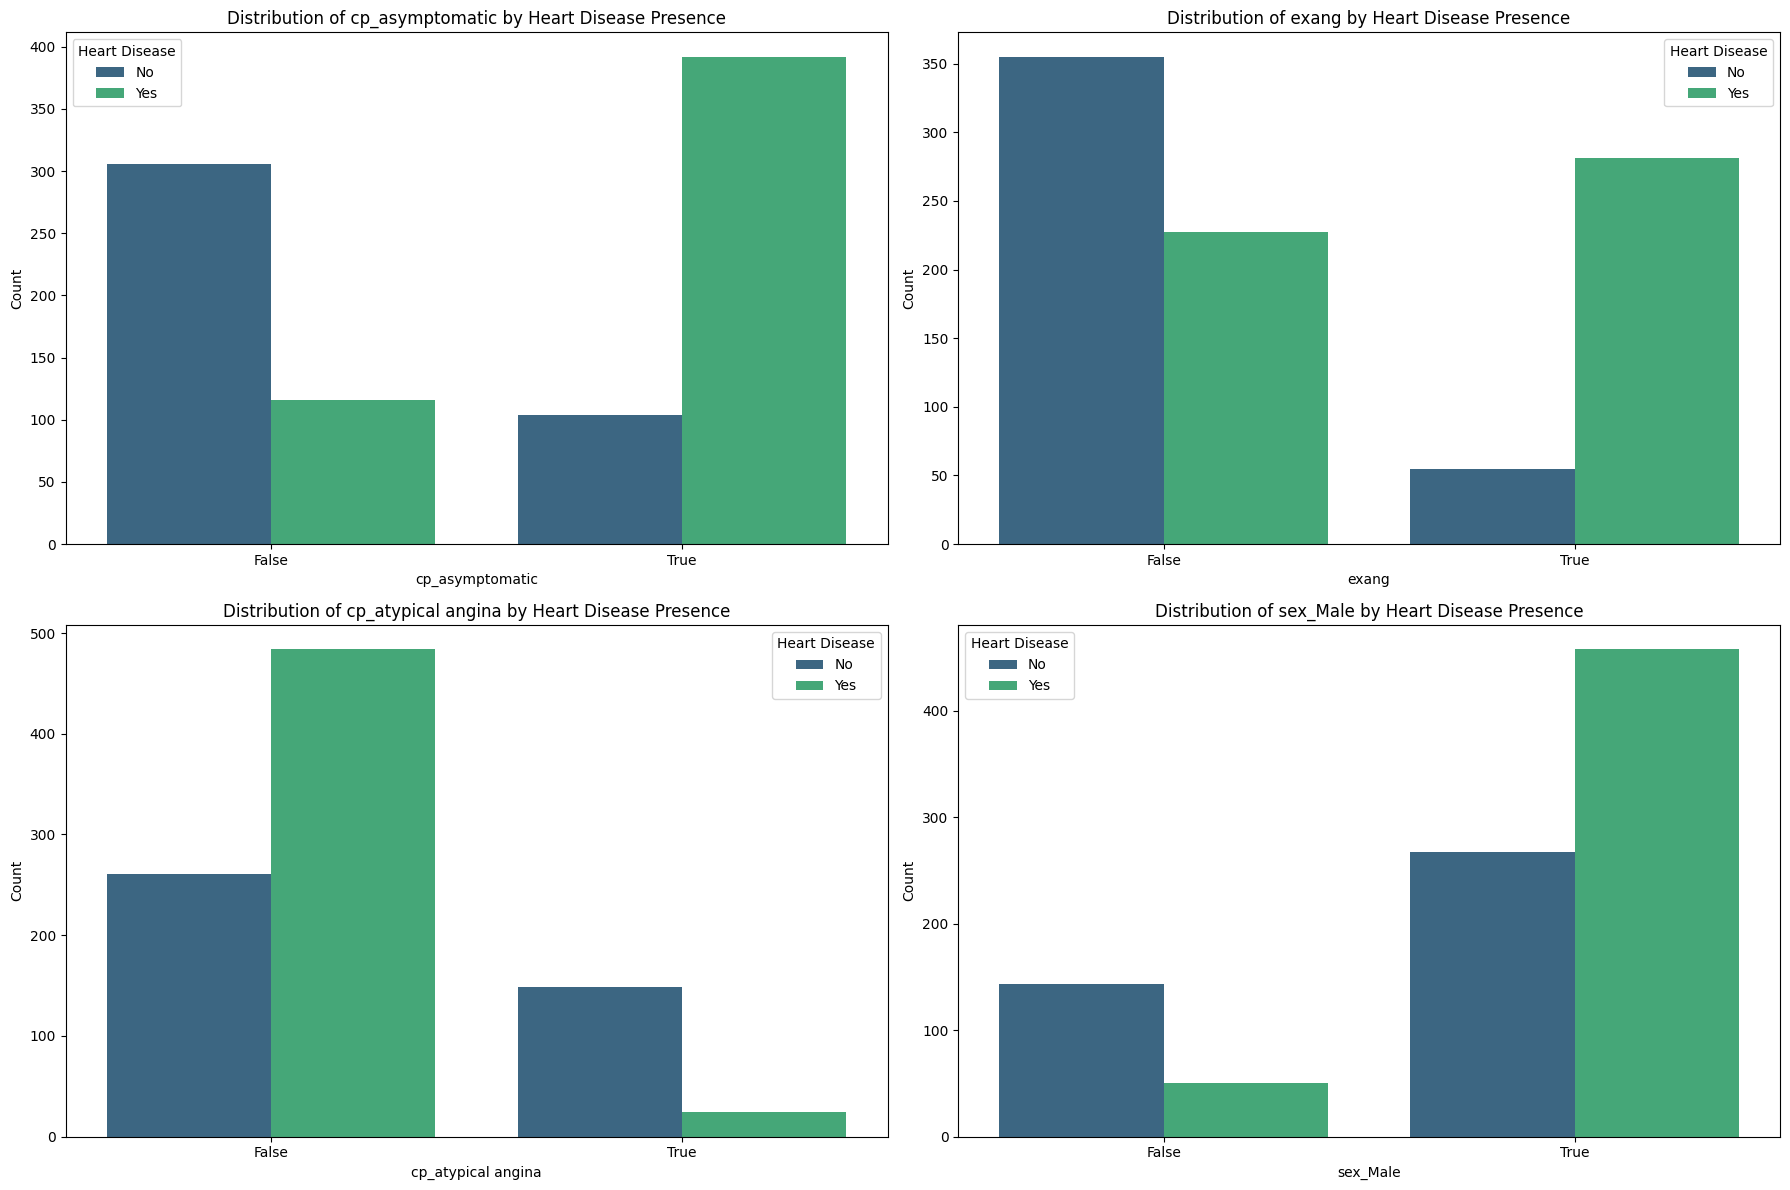

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

top_categorical_features = ['cp_asymptomatic', 'exang', 'cp_atypical angina', 'sex_Male']

plt.figure(figsize=(18, 12))
for i, col in enumerate(top_categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=X[col], hue=y, palette='viridis')
    plt.title(f'Distribution of {col} by Heart Disease Presence')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

#Distribution of Age by Heart Disease Presence

/tmp/ipykernel_37113/3985616844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['age'], palette='viridis')


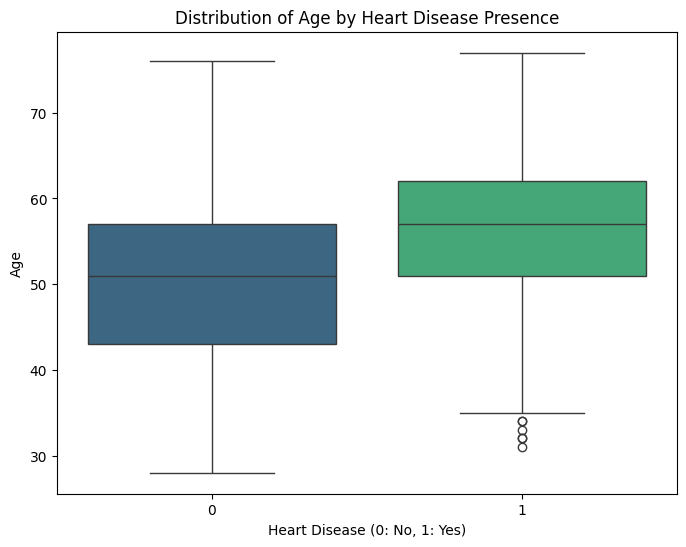

In [88]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X['age'], palette='viridis')
plt.title('Distribution of Age by Heart Disease Presence')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

#feature scaling

In [89]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude boolean columns as they are already in a binary format (0/1) which is often not scaled
# 'fbs' is also 0/1 and does not need scaling
numerical_features_for_scaling = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical features
X[numerical_features_for_scaling] = scaler.fit_transform(X[numerical_features_for_scaling])

print("X after feature scaling:")
display(X.head())

X after feature scaling:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,1.006537,0.697934,0.310887,2.377430,0.495664,False,1.347160,True,False,False,False,True,False,False,False,False
1,1.430829,1.511822,0.797058,-0.420622,-1.175447,True,0.587821,True,True,False,False,True,False,False,True,False
2,1.430829,-0.658547,0.274194,-0.420622,-0.339892,True,1.631912,True,True,False,False,True,False,False,True,False
3,-1.751359,-0.115955,0.466829,-0.420622,1.967833,False,2.486169,True,False,False,True,False,True,False,False,False
4,-1.327067,-0.115955,0.044868,-0.420622,1.371007,False,0.492904,False,False,True,False,True,False,False,False,True


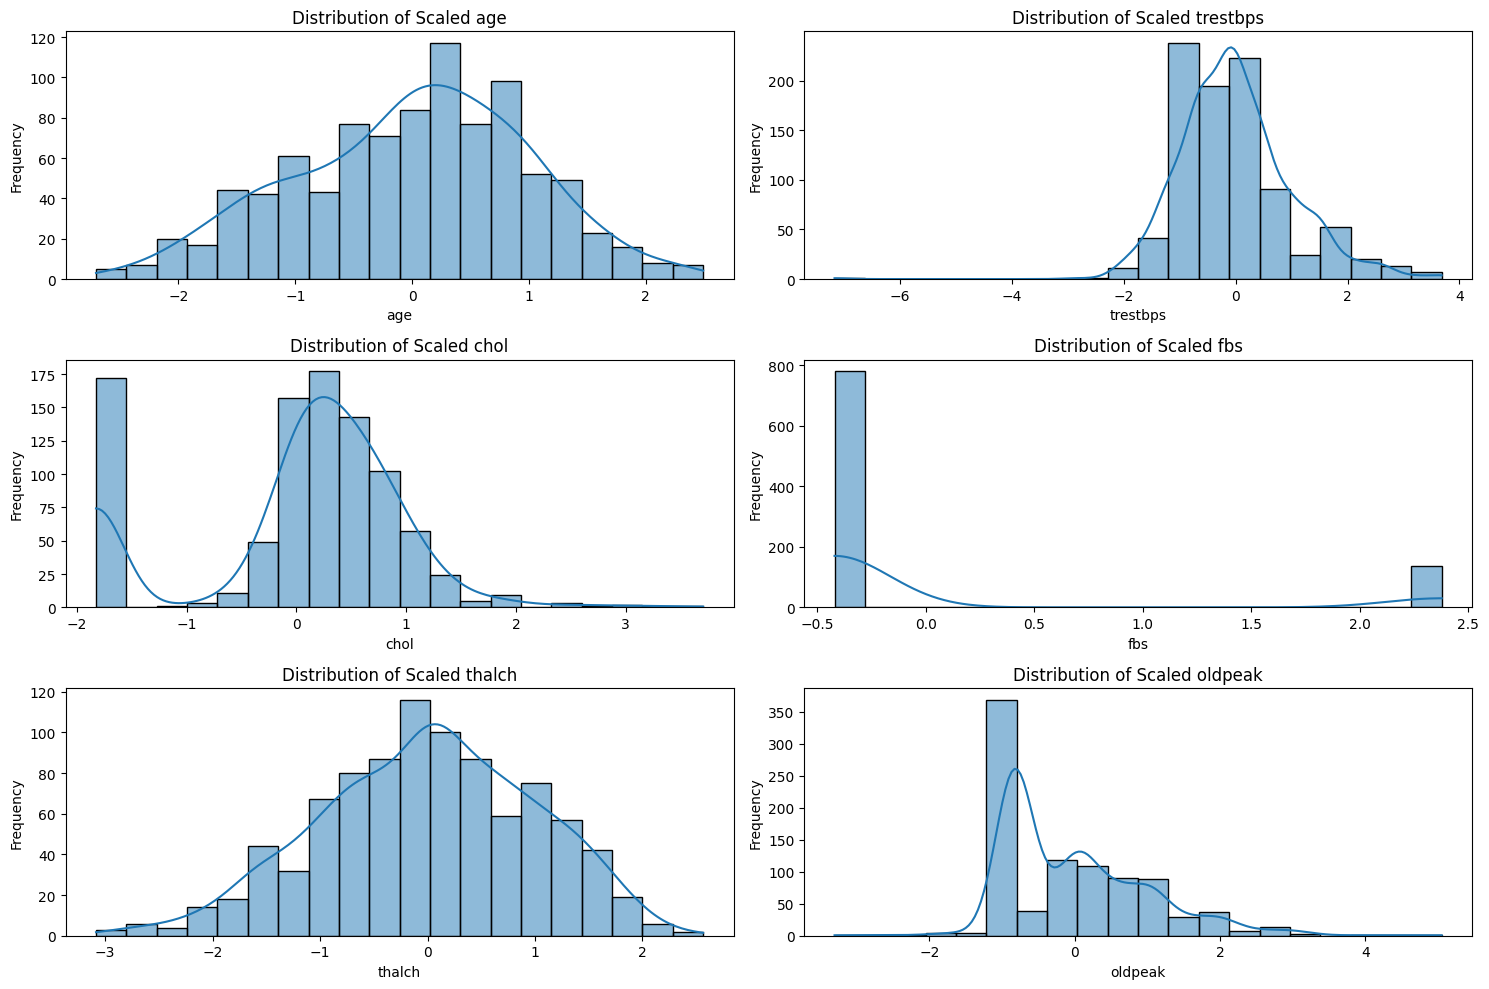

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_features_for_scaling = X.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_scaling):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(X[col], kde=True, bins=20)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#correlation matrix for the scaled features

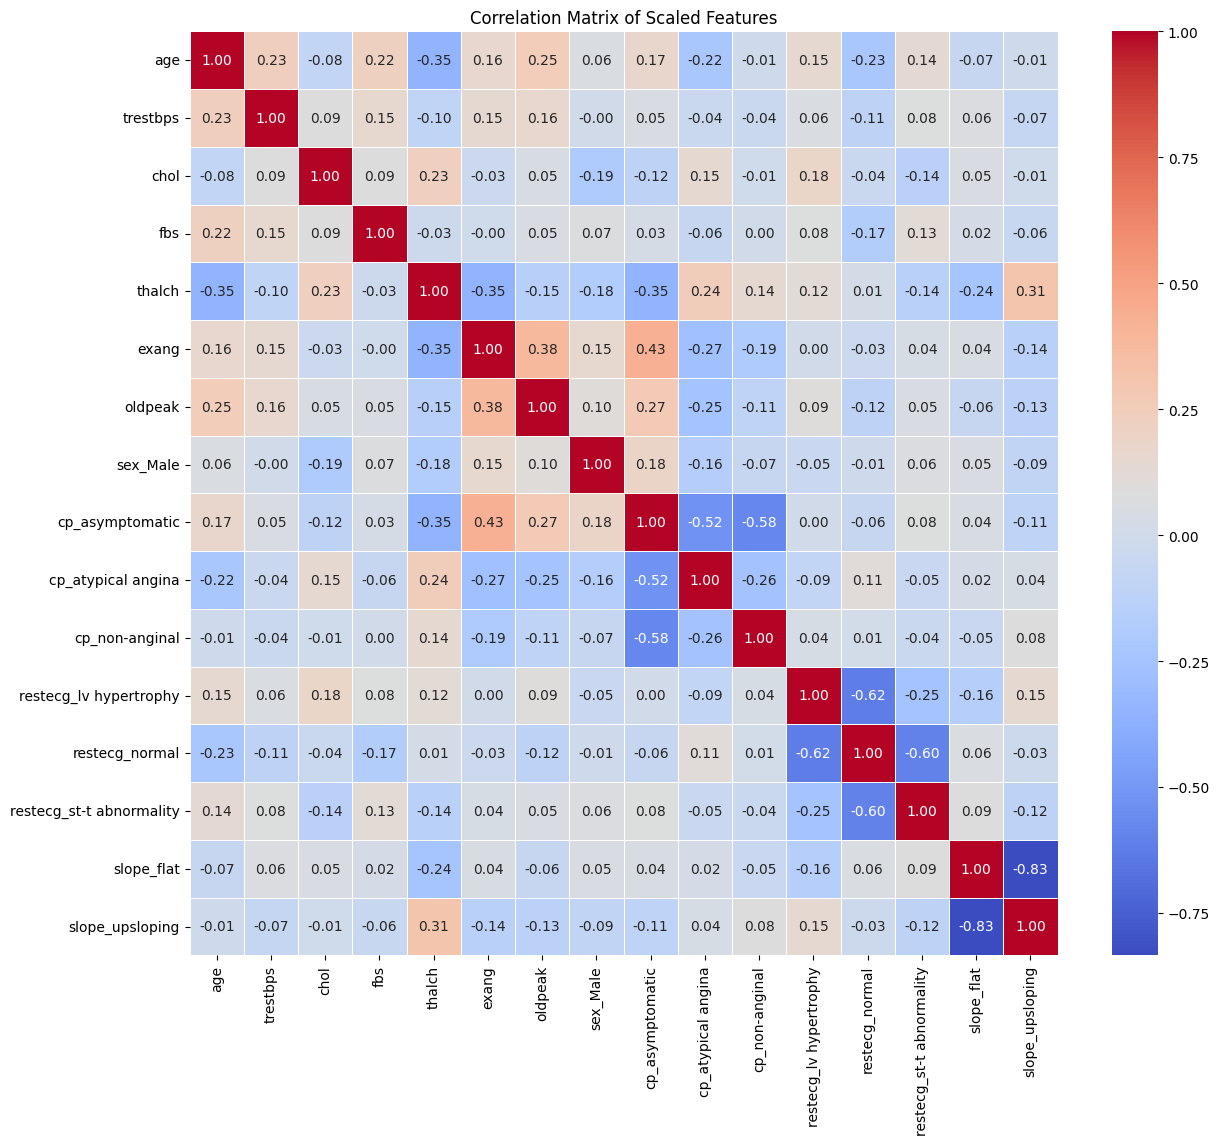

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the scaled features
corr_matrix_scaled = X.corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_scaled, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Scaled Features')
plt.show()

In [92]:
print("Displaying the first 5 rows of X after scaling:")
display(X.head())

Displaying the first 5 rows of X after scaling:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,1.006537,0.697934,0.310887,2.377430,0.495664,False,1.347160,True,False,False,False,True,False,False,False,False
1,1.430829,1.511822,0.797058,-0.420622,-1.175447,True,0.587821,True,True,False,False,True,False,False,True,False
2,1.430829,-0.658547,0.274194,-0.420622,-0.339892,True,1.631912,True,True,False,False,True,False,False,True,False
3,-1.751359,-0.115955,0.466829,-0.420622,1.967833,False,2.486169,True,False,False,True,False,True,False,False,False
4,-1.327067,-0.115955,0.044868,-0.420622,1.371007,False,0.492904,False,False,True,False,True,False,False,False,True


#Top 5 features based on F-Score and Features with P-Value < 0.05

In [93]:
# Select the top 5 features based on F-Score
top_5_features_f_score = feature_selection_results.head(5)
print("Top 5 features based on F-Score:")
display(top_5_features_f_score)

# Select features with a p-value less than 0.05
significant_features_p_value = feature_selection_results[feature_selection_results['P-Value'] < 0.05]
print("Features with P-Value < 0.05:")
display(significant_features_p_value)

Top 5 features based on F-Score:


,Feature,F-Score,P-Value
8,cp_asymptomatic,333.651942,8.415228e-64
5,exang,210.678446,4.042628e-43
9,cp_atypical angina,176.482905,5.868475e-37
4,thalch,156.328942,3.120176e-33
6,oldpeak,148.402258,9.539159e-32


Features with P-Value < 0.05:


,Feature,F-Score,P-Value
8,cp_asymptomatic,333.651942,8.415228e-64
5,exang,210.678446,4.042628e-43
9,cp_atypical angina,176.482905,5.868475e-37
4,thalch,156.328942,3.120176e-33
6,oldpeak,148.402258,9.539159e-32
7,sex_Male,94.253184,2.821898e-21
0,age,79.160779,3.007953e-18
2,chol,49.719312,3.492421e-12
10,cp_non-anginal,43.517481,7.096217e-11
17,slope_upsloping,31.126535,3.182880e-08


## Identify and drop features with p-value > 0.05

In [94]:
# Identify features with p-value > 0.05
features_to_drop_high_p_value = feature_selection_results[feature_selection_results['P-Value'] >= 0.05]['Feature'].tolist()

print(f"Features to be dropped due to P-Value >= 0.05: {features_to_drop_high_p_value}")

# Drop these columns from X
X = X.drop(columns=features_to_drop_high_p_value, errors='ignore')

print("\nFeatures remaining in X after dropping columns with P-Value >= 0.05:")
display(X.columns)

print("\nShape of X after dropping columns:")
print(X.shape)

Features to be dropped due to P-Value >= 0.05: ['cp_typical angina', 'restecg_lv hypertrophy']

Features remaining in X after dropping columns with P-Value >= 0.05:


Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'restecg_normal', 'restecg_st-t abnormality', 'slope_flat',
       'slope_upsloping'],
      dtype='object')


Shape of X after dropping columns:
(918, 15)


#Variance Inflation Factor (VIF) for each feature

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Ensure all columns in X are numeric for VIF calculation
# Convert boolean columns to integer (0 or 1)
X_numeric_vif = X.copy()
for col in X_numeric_vif.select_dtypes(include='bool').columns:
    X_numeric_vif[col] = X_numeric_vif[col].astype(int)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_vif.values, i) for i in range(len(X_numeric_vif.columns))]

print("Variance Inflation Factor (VIF) for each feature:")
display(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:


,feature,VIF
13,slope_flat,8.527759
8,cp_asymptomatic,7.960477
7,sex_Male,4.729234
11,restecg_normal,4.130575
10,cp_non-anginal,3.504071
14,slope_upsloping,3.418516
9,cp_atypical angina,3.263278
5,exang,2.291685
12,restecg_st-t abnormality,2.042503
4,thalch,1.549022


# Identify features to drop based on VIF

In [96]:
# Set a VIF threshold for removal
vif_threshold = 5

# Identify features to drop based on VIF
features_to_drop_vif = vif_data[vif_data['VIF'] >= vif_threshold]['feature'].tolist()

# If there are features to drop, drop them one by one and re-calculate VIF
while len(features_to_drop_vif) > 0:
    # Always drop the feature with the highest VIF first as it has the most impact
    highest_vif_feature = vif_data.sort_values(by='VIF', ascending=False).iloc[0]['feature']

    # Only drop if its VIF is above the threshold
    if vif_data.sort_values(by='VIF', ascending=False).iloc[0]['VIF'] >= vif_threshold:
        print(f"Dropping feature with highest VIF: {highest_vif_feature} (VIF: {vif_data[vif_data['feature'] == highest_vif_feature]['VIF'].iloc[0]:.2f})")
        X = X.drop(columns=[highest_vif_feature])

        # Re-calculate VIFs for remaining features
        X_numeric_vif = X.copy()
        for col in X_numeric_vif.select_dtypes(include='bool').columns:
            X_numeric_vif[col] = X_numeric_vif[col].astype(int)

        # Ensure there are at least 2 features remaining for VIF calculation
        if X_numeric_vif.shape[1] > 1:
            vif_data = pd.DataFrame()
            vif_data["feature"] = X_numeric_vif.columns
            vif_data["VIF"] = [variance_inflation_factor(X_numeric_vif.values, i) for i in range(len(X_numeric_vif.columns))]

            # Update features to drop for the next iteration
            features_to_drop_vif = vif_data[vif_data['VIF'] >= vif_threshold]['feature'].tolist()
        else:
            print("Stopped VIF reduction: too few features remaining.")
            break # Exit if only one or no features left
    else:
        print("No more features with VIF >= threshold to drop.")
        break # Exit if highest VIF is below threshold

print("\nFinal Variance Inflation Factor (VIF) for remaining features:")
display(vif_data.sort_values(by='VIF', ascending=False))

print("\nFeatures remaining in X after VIF reduction:")
display(X.columns)

print("\nShape of X after VIF reduction:")
print(X.shape)

Dropping feature with highest VIF: slope_flat (VIF: 8.53)
Dropping feature with highest VIF: cp_asymptomatic (VIF: 5.37)

Final Variance Inflation Factor (VIF) for remaining features:


,feature,VIF
7,sex_Male,3.389386
10,restecg_normal,2.977719
5,exang,2.035890
11,restecg_st-t abnormality,1.641614
8,cp_atypical angina,1.558232
4,thalch,1.544993
9,cp_non-anginal,1.408475
12,slope_upsloping,1.402949
0,age,1.371057
6,oldpeak,1.301434



Features remaining in X after VIF reduction:


Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_upsloping'],
      dtype='object')


Shape of X after VIF reduction:
(918, 13)


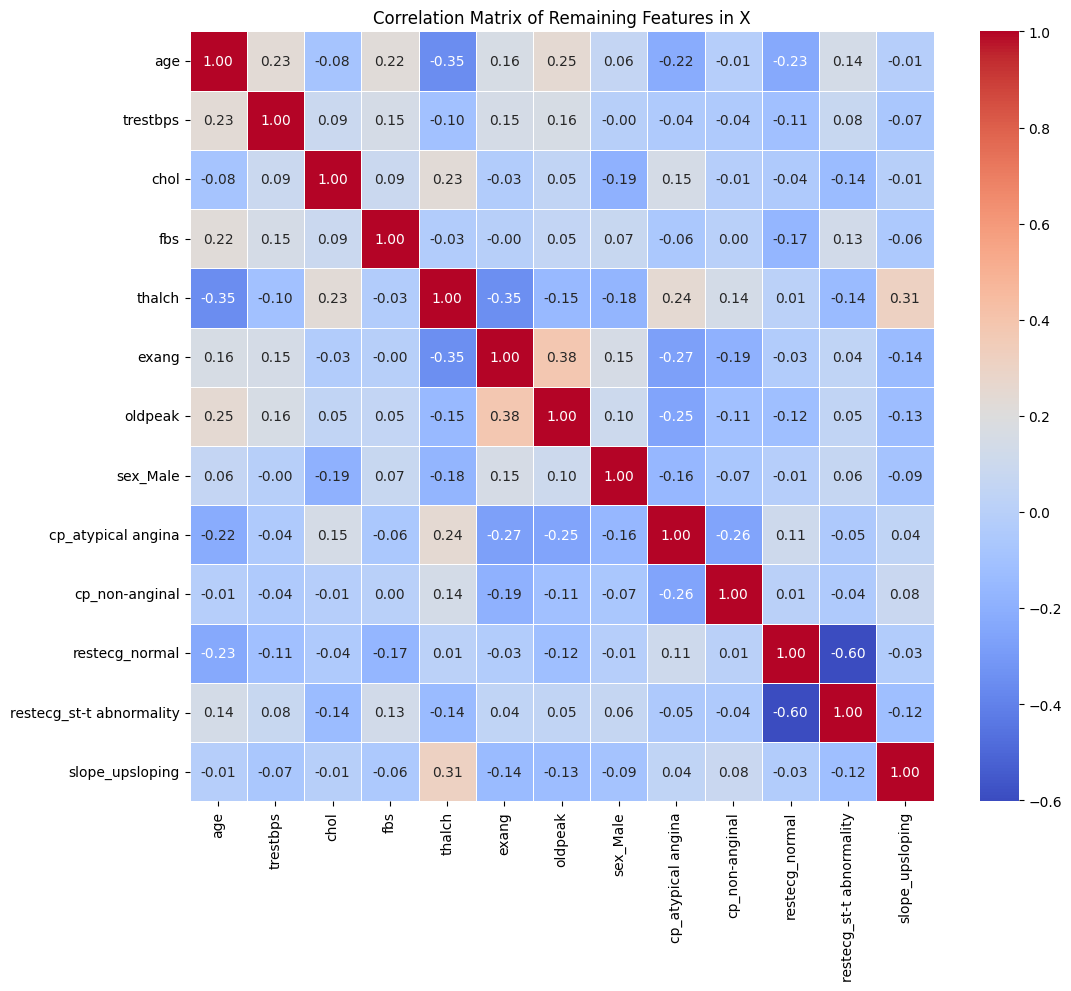

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the remaining features in X
corr_matrix_final = X.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_final, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Remaining Features in X')
plt.show()

# train test

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (734, 13)
Shape of X_test: (184, 13)
Shape of y_train: (734,)
Shape of y_test: (184,)


### Build and Train Logistic Regression Model

In [99]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and handles L1/L2 penalties.
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Evaluate the Model

In [100]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8315217391304348

Confusion Matrix:
 [[62 20]
 [11 91]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.76      0.80        82
           1       0.82      0.89      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.83       184
weighted avg       0.83      0.83      0.83       184



### Calculate ROC-AUC Score

In [101]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9063


### Hyperparameter Tuning using GridSearchCV

In [102]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
# We'll use the 'liblinear' solver which supports both 'l1' and 'l2' penalties.
grid_search = GridSearchCV(LogisticRegression(solver='liblinear', random_state=42),
                           param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='accuracy', # Use accuracy as the scoring metric
                           n_jobs=-1, # Use all available CPU cores
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best parameters found:  {'C': 10, 'penalty': 'l2'}
Best cross-validation accuracy:  0.8038673003447954


### Evaluate the Tuned Model

In [105]:
# Make predictions with the best model
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nTuned Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nTuned Model Classification Report:\n", classification_report(y_test, y_pred_tuned))
print(f"\nTuned Model ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Tuned Model Accuracy: 0.8369565217391305

Tuned Model Confusion Matrix:
 [[63 19]
 [11 91]]

Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Tuned Model ROC-AUC Score: 0.9067


### Interpret Logistic Regression Coefficients

In [106]:
import pandas as pd

# Get coefficients from the best tuned model
coefficients = best_model.coef_[0]

# Get feature names from X_train (since it was used to train the best_model)
feature_names = X_train.columns

# Create a DataFrame for better readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value to see most impactful features
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("Logistic Regression Coefficients (Tuned Model):")
display(coef_df)

Logistic Regression Coefficients (Tuned Model):


,Feature,Coefficient
8,cp_atypical angina,-1.914927
7,sex_Male,1.242069
5,exang,1.188668
9,cp_non-anginal,-1.135450
12,slope_upsloping,-0.463999
6,oldpeak,0.425217
4,thalch,-0.328183
0,age,0.305629
10,restecg_normal,-0.299406
2,chol,-0.297753


In [107]:
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print("Logistic Regression Coefficients and Odds Ratios (Tuned Model):")
display(coef_df)

Logistic Regression Coefficients and Odds Ratios (Tuned Model):


,Feature,Coefficient,Odds_Ratio
8,cp_atypical angina,-1.914927,0.147353
7,sex_Male,1.242069,3.462772
5,exang,1.188668,3.282706
9,cp_non-anginal,-1.135450,0.321278
12,slope_upsloping,-0.463999,0.628764
6,oldpeak,0.425217,1.529922
4,thalch,-0.328183,0.720231
0,age,0.305629,1.357478
10,restecg_normal,-0.299406,0.741258
2,chol,-0.297753,0.742485


### Logistic Regression Assumptions Check



In [108]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate predicted probabilities on the training data
# We use the best_model from GridSearchCV
probabilities = best_model.predict_proba(X_train)[:, 1]

# Calculate the log-odds (logit)
# Add a small epsilon to probabilities to avoid log(0) or log(1) errors
epsilon = 1e-10
log_odds = np.log((probabilities + epsilon) / (1 - probabilities + epsilon))

print("Calculated log-odds for training data.")

Calculated log-odds for training data.


Continuous features to check linearity: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak']


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


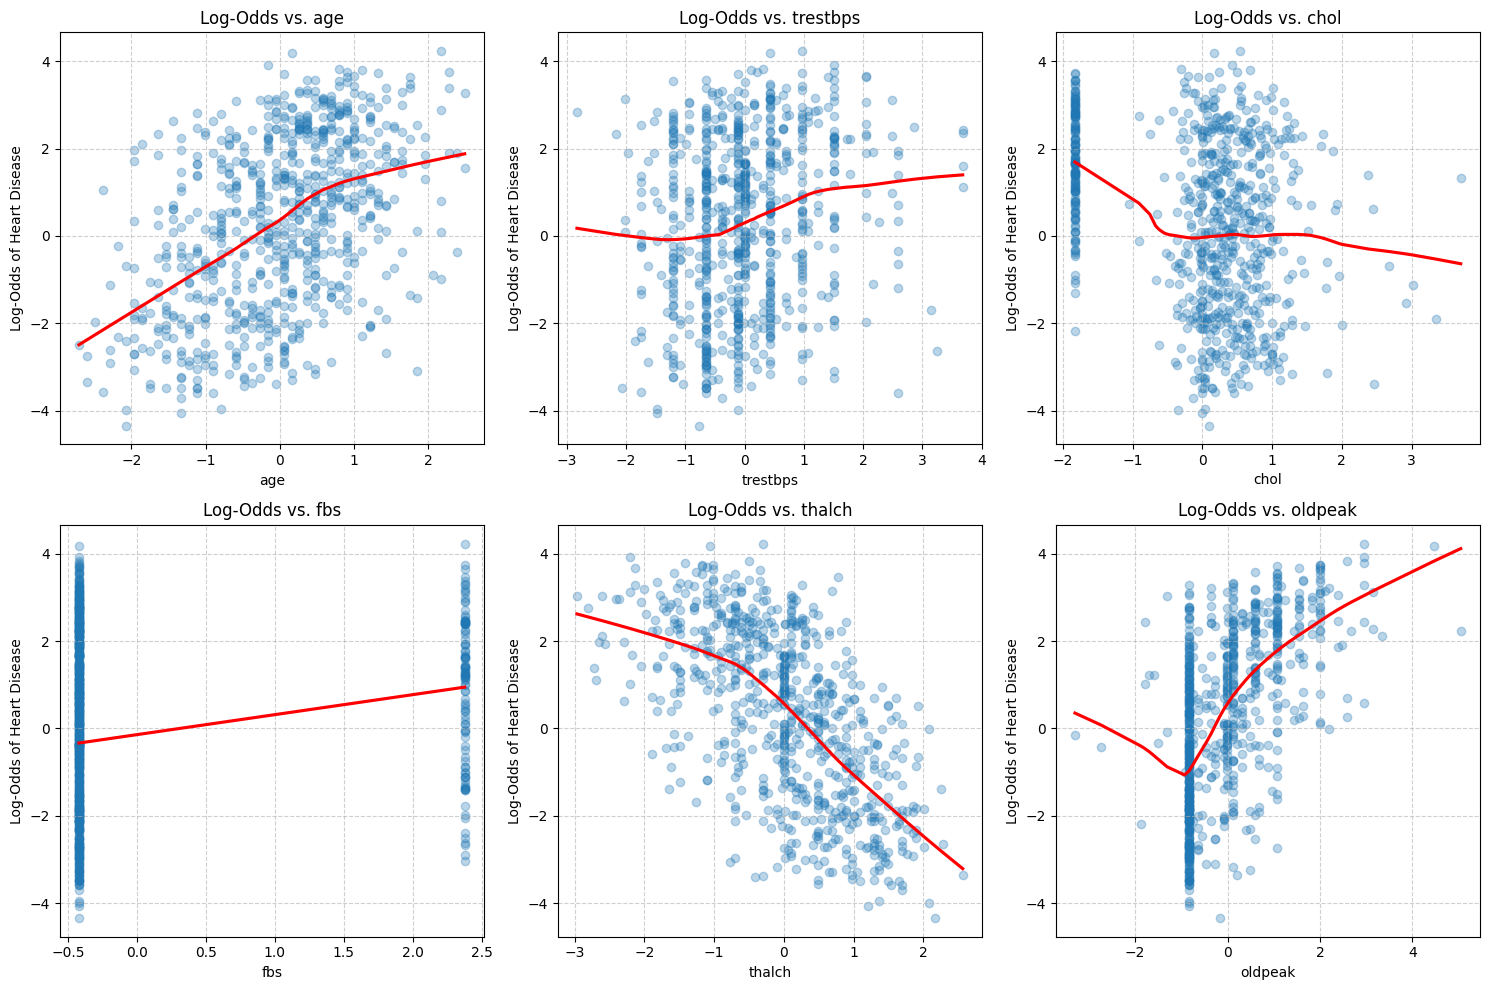

In [109]:
# Identify continuous numerical features remaining in X_train
# We exclude boolean features as they are not continuous
continuous_features = X_train.select_dtypes(include=np.number).columns.tolist()

print("Continuous features to check linearity:", continuous_features)

plt.figure(figsize=(15, 10))
for i, feature in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.regplot(x=X_train[feature], y=log_odds, lowess=True,
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f'Log-Odds vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Log-Odds of Heart Disease')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
